# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [44]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝
for name, model in base_models.items():
    cv = cross_val_score(model, X=X_train, y=y_train, cv=5, scoring='f1_macro')
    model.fit(X_train, y_train)
    baseline_results[name] = (cv.mean(), cv.std())
# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")


SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [46]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
   'svm__C': [0.1, 1, 10, 100],
   'svm__gamma': ['scale', 0.01, 0.001],
   'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(estimator=svm_pipe, param_grid=svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X=X_train,y=y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [47]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

cv_df = pd.DataFrame(svm_grid_search.cv_results_)[["params", "mean_test_score", "std_test_score"]]
cv_df.head(10)

,params,mean_test_score,std_test_score
0,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.940340,0.020136
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266
2,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.937500,0.014005
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266
4,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.638684,0.043638
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323
7,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.964626,0.014950
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212
9,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.964626,0.014950


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    "n_estimators": randint(50,500),
    "max_depth": [None] + list(range(2,20)),
    "min_samples_split": randint(2,20),
    "max_features": ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                                       param_distributions=rf_param_dist, 
                                       n_iter=50, 
                                       cv=5,
                                       scoring='f1_macro', 
                                       random_state=42, 
                                       n_jobs=-1)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 19, 'max_features': 0.5, 'min_samples_split': 4, 'n_estimators': 356}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [49]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
score_df = pd.DataFrame({
    "Модель": ["SVM baseline", "SVM Grid Search", "RF baseline", "Random Search"],
    "CV F1": [
        baseline_results["SVM"][0],
        svm_grid_search.best_score_,
        baseline_results["RandomForest"][0],
        rf_random_search.best_score_
    ],
    "Test F1": [
        f1_score(y_test, base_models["SVM"].predict(X_test)),
        f1_score(y_test, svm_grid_search.predict(X_test)),
        f1_score(y_test, base_models["RandomForest"].predict(X_test)),
        f1_score(y_test, rf_random_search.predict(X_test)),
    ]
})

svm_cv_f1 = svm_grid_search.best_score_
rf_cv_f1 = rf_random_search.best_score_


display(score_df)
# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

,Модель,CV F1,Test F1
0,SVM baseline,0.969357,0.986111
1,SVM Grid Search,0.978633,0.986111
2,RF baseline,0.950427,0.965517
3,Random Search,0.955356,0.965517


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

<BarContainer object of 10 artists>

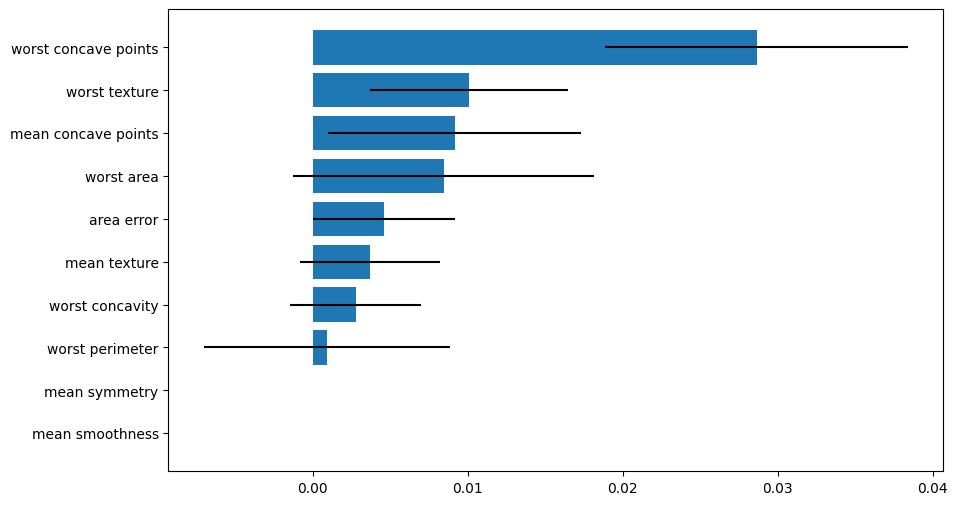

In [50]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_macro')

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
feature_names = X.columns

importances_df = pd.DataFrame({
"feature": feature_names,
"importance_mean": pi_result.importances_mean,
"importance_std": pi_result.importances_std
})

top_10 = importances_df.sort_values("importance_mean", ascending=False).head(10)
top_10_reverse = top_10.sort_values("importance_mean", ascending=True).head(10)
plt.figure(figsize=(10, 6))
plt.barh(
    top_10_reverse["feature"],
    top_10_reverse["importance_mean"],
    xerr=top_10_reverse["importance_std"])

In [51]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
display(top_10.head(5))
rf_importances_ = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf.feature_importances_
})
display(rf_importances_.sort_values("importance",ascending=False).head(5))
# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

,feature,importance_mean,importance_std
27,worst concave points,0.028624,0.009783
21,worst texture,0.010080,0.006399
7,mean concave points,0.009154,0.008154
23,worst area,0.008427,0.009737
13,area error,0.004593,0.004593


,feature,importance
22,worst perimeter,0.226221
27,worst concave points,0.186988
23,worst area,0.141626
20,worst radius,0.137676
7,mean concave points,0.115230


### некоторые признаки не совпали, в том числе порядок не совпадает. это связано с тем, что встроенная важность в RF рассчитывается по индексу Джини, который основан на делении дерева. А Permutation Importance рассчитывается после обучения модели при помощи перемешивания значений одного признака. обычно считается, что permutation importance - точнее.

низкий PI, высокая встроенная важность - слабо коррелирующий признак (встроенная важность будет распределяться между всеми коррелирующими признаками, а в PI - он будет просто очень низким.)
ИЛИ переобучение, тк при нем модель построит глубокие деревья с высокой встроенной важностью, а PI останется низким или даже станет отрицательным

высокий PI, низкая встроенная важность - признак может содержать уникальную информаци, критически важную для предсказания, но недооценённую при обучении (часто - категориальные признаки, по которым дерево маловероято будет делить часто)

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

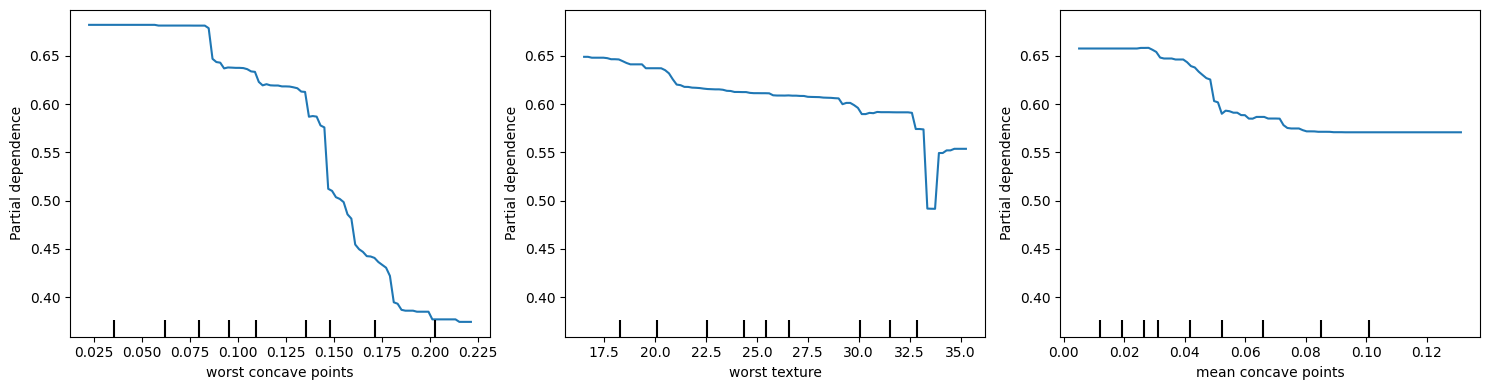

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = top_10.head(3).index.to_list()
# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_test,
    features=top3_idx,
    kind='average',
    ax=ax
)

plt.tight_layout()
plt.show()

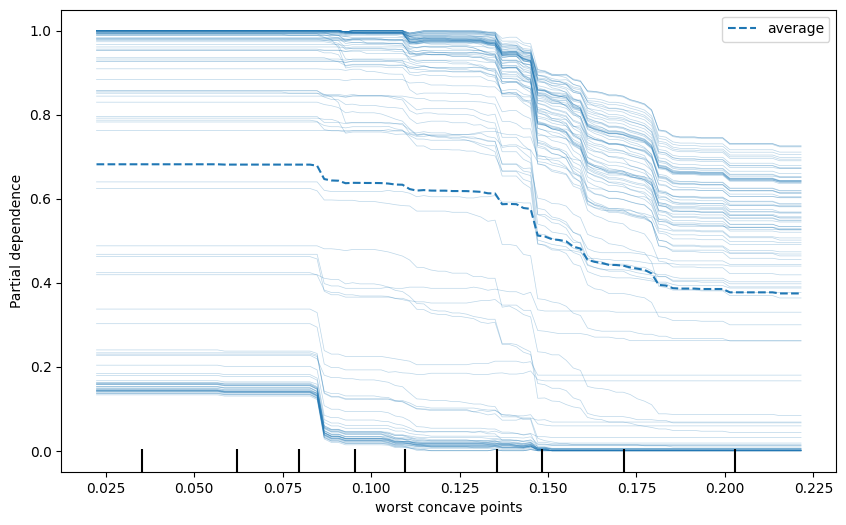

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝
most_important_feature = top_10['feature'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

PartialDependenceDisplay.from_estimator(
    estimator=best_rf,
    X=X_test,
    features=[most_important_feature],
    kind='both',
    ax=ax
)

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [54]:
# Установка SHAP (если не установлен)
#!pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
print(f"Shape of shap_values: {np.shape(shap_values)}")

Shape of shap_values: (114, 30, 2)


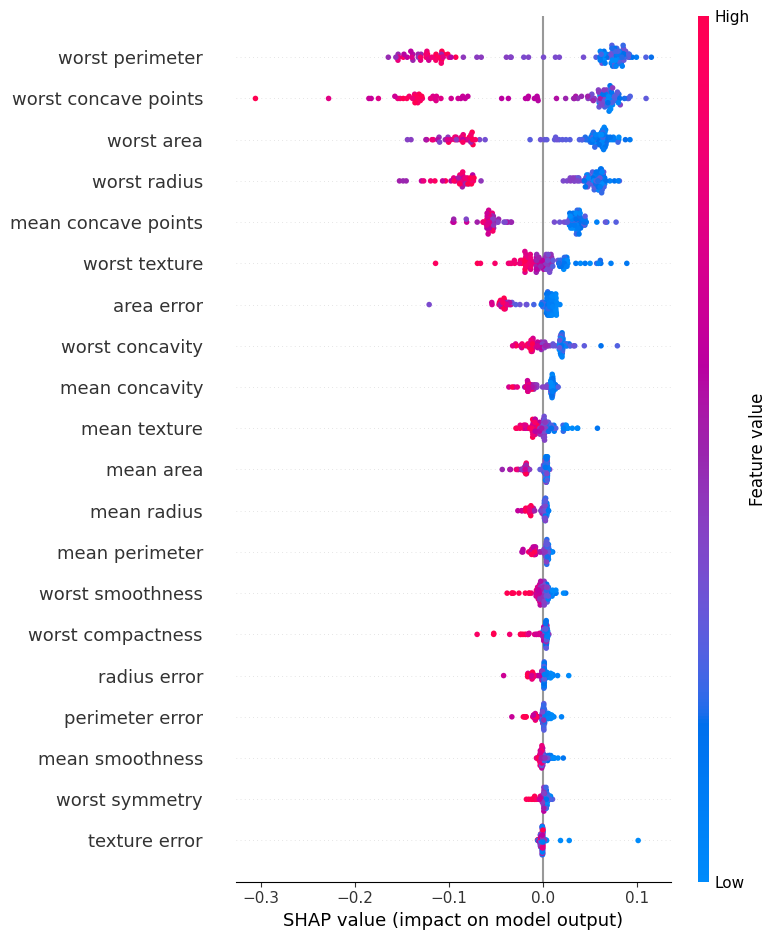

In [55]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

shap.summary_plot(shap_values[:,:,1], X_test)

### Ответ на 8б:

По SHAP summary plot самые важные признаки для класса 1:
1. **worst perimeter** - максимальное среднее абсолютное значение SHAP
2. **worst concaive points** - второе место по важности
3. **worst area** - третье место

**Совпадает ли с PI?**
Да, эти же три признака занимают топ-3 позиции и по PI. Порядок немного отличается, но в целом картинка похожая. Разница обучловлена тем,Ж что PI измеряет вклад в метрику F1 (глобально), а SHAP показывает среднее локальное влияние на предсказание. 

Корреляция этих признаков высокая, они все описывают геометрические размеры опухоли, поэтому оба метода выделяют одну и ту же группу критически важных признаков.

In [56]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

if(len(errors) > 0):
    err_idx = errors[0]
    patient_shap = shap_values[err_idx,:,1]
    shap.initjs()
    plot = shap.plots.force(
        base_value=explainer.expected_value[1],
        shap_values=patient_shap,
        features=X_test.iloc[err_idx]
    )
    display(plot)
else:
    print("Ошибок нет!")

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


В ошибке виноваты геометрические параметры размера опухоли worst area, worst perimeter, worst radius. Опухоль оказалась нетипично большой для доброкачественной, что и запутало модель, несмотря на то, что структура клеток (worst concave points и worst concavity) указывала на доброкачественный характер.

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [57]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

,feature_name,mean_importances
30,leaky_feature,0.261404
7,mean concave points,0.004386
27,worst concave points,0.003509
0,mean radius,0.000000
3,mean area,0.000000
4,mean smoothness,0.000000
2,mean perimeter,0.000000
1,mean texture,0.000000
8,mean symmetry,0.000000
9,mean fractal dimension,0.000000


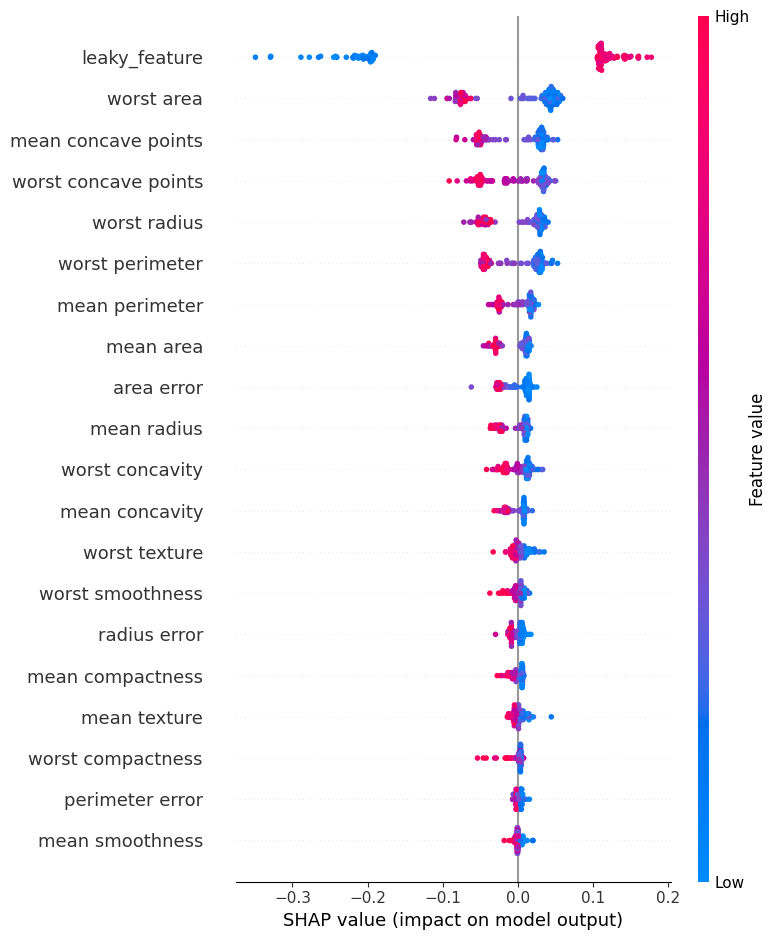

In [58]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝
ext_rf = RandomForestClassifier(random_state=42)
ext_rf.fit(X_train_ext, y_train)

pi = permutation_importance(ext_rf, X_test_ext, y_test,random_state=42, n_repeats=10)

ext_pi = pd.DataFrame({
    'feature_name': X_test_ext.columns,
    'mean_importances': pi.importances_mean
})
display(ext_pi.sort_values(by='mean_importances', ascending=False).head(10))
ext_explainer = shap.TreeExplainer(ext_rf)
shap_values = ext_explainer.shap_values(X_test_ext)
shap.summary_plot(shap_values[:,:,1], X_test_ext)

In [59]:

# Доказательство: сравним F1 на тесте с и без утечки

from sklearn.metrics import f1_score

f1_without_leak = f1_score(y_test, best_rf.predict(X_test))

f1_with_leak = f1_score(y_test, ext_rf.predict(X_test_ext))

print("="*60)
print("ДОКАЗАТЕЛЬСТВО: Катастрофический рост качества из-за утечки")
print("="*60)
print(f"F1 без leaky_feature:     {f1_without_leak:.4f}")
print(f"F1 с leaky_feature:       {f1_with_leak:.4f}")
print(f"Улучшение:                {(f1_with_leak - f1_without_leak)*100:.2f} процентных пункта")
print("="*60)


ДОКАЗАТЕЛЬСТВО: Катастрофический рост качества из-за утечки
F1 без leaky_feature:     0.9655
F1 с leaky_feature:       1.0000
Улучшение:                3.45 процентных пункта


**a) PI vs leaky_feature:**
leaky_feature показала PI = 0.261404 — максимальная среди всех признаков. При перемешивании этого признака F1 падает на 0.26 пункта. Остальные признаки имеют PI близкую к нулю. F1 вырос с 0.9655 до 1.0000 — модель полностью полагается на утечку.

**б) SHAP на утечке:**
leaky_feature заняла доминирующую позицию в summary plot с максимальными SHAP values, которые сильно отклоняются от нулевой линии. Модель строит решения только вокруг этого признака. Модуль SHAP значения всегда > 0.1 — все точки на графике далеко за пределами [-0.1, 0.1].

**в) Обнаружение random_feature:**
random_feature в конце списка с PI = 0. Деревья её вообще не использовали и при перемешивании ни выигрыша, ни особого проигрыша от фичи нет. Это относится к любому шуму, на котором нельзя построить логичную закономерность.

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [60]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

summary_table = pd.DataFrame({
    "Метод": ["SVM baseline", "SVM Grid Search", "RF baseline", "RF Random Search"],
    "CV F1": [
        baseline_results["SVM"][0],
        svm_grid_search.best_score_,
        baseline_results["RandomForest"][0],
        rf_random_search.best_score_
    ],
    "Test F1": [
        f1_score(y_test, base_models["SVM"].predict(X_test)),
        f1_score(y_test, svm_grid_search.predict(X_test)),
        f1_score(y_test, base_models["RandomForest"].predict(X_test)),
        f1_score(y_test, rf_random_search.predict(X_test)),
    ]
})

display(summary_table)

,Метод,CV F1,Test F1
0,SVM baseline,0.969357,0.986111
1,SVM Grid Search,0.978633,0.986111
2,RF baseline,0.950427,0.965517
3,RF Random Search,0.955356,0.965517


### Выводы:

**1. Насколько тюнинг улучшил модели?**
SVM улучшился на ~0.0093 (с 0.9694 до 0.9786 в CV F1), RF на ~0.0049 (с 0.9504 до 0.9554 в CV F1). Тюнинг дал скромный прирост качества (что в целом логично, тк у нас и так были достаточно точные модели. На более сложных данных, где baseline модели выдавали бы f1 в районе 87%, например, вклад тюнинга был бы более показательным.). Заметнее всего то, что Test F1 остался одинаковым: SVM — 0.9861, RF — 0.9655, без переобучения.

**2. Совпадают ли топ-признаки по PI и SHAP?**
Нет полного совпадения. worst area и mean concave points лидируют в обоих методах, но порядок отличается. PI считает вклад в метрику после перемешивания, SHAP — локальный вклад каждого объекта. Если признак коррелирует с другими, PI может недооценить его, а SHAP покажет реальное влияние на конкретное решение.

**3. Что было бы, если бы мы не использовали Pipeline?**
Без Pipeline нужно было бы нормировать данные вручную перед SVM (иначе большие признаки доминируют). Pipeline гарантирует, что нормировка не утечёт из тренировки в тест и параметры нормировки не портят результаты. Это критично для корректной кросс-валидации.

**4. Как бы вы использовали PI и SHAP в реальном проекте?**
- **PI**: быстрая проверка значимости признаков, выявление утечек, шума. Можно регулярно пересчитывать после обновления данных.
- **SHAP**: для дебага ошибок - почему модель предсказала неправильно? Какой признак в конкретном случае внёс решающий вклад? Для объяснения бизнесу - какие факторы влияют на решение? Для мониторинга дрифта - если SHAP распределения меняются, модель портится. Однако KernelExplainer работает за O(n * 2^m), что на датасете с большим количество фич будет считаться ОЧЕНЬ долго. Поэтому его можно использовать только для диагностики или небольшой подвыборки. Его специализированные эксплейнеры TreeExplainer и LinearExplainer оптимизированы под конкретные модели и работают намного быстрее.

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

Optuna нашла лучшее за 7 trials: 0.9577
Random Search нашла лучшее за 9 trials: 0.9554

Лучшие параметры Optuna: {'n_estimators': 178, 'max_depth': 10, 'min_samples_split': 3, 'max_features': 'sqrt'}


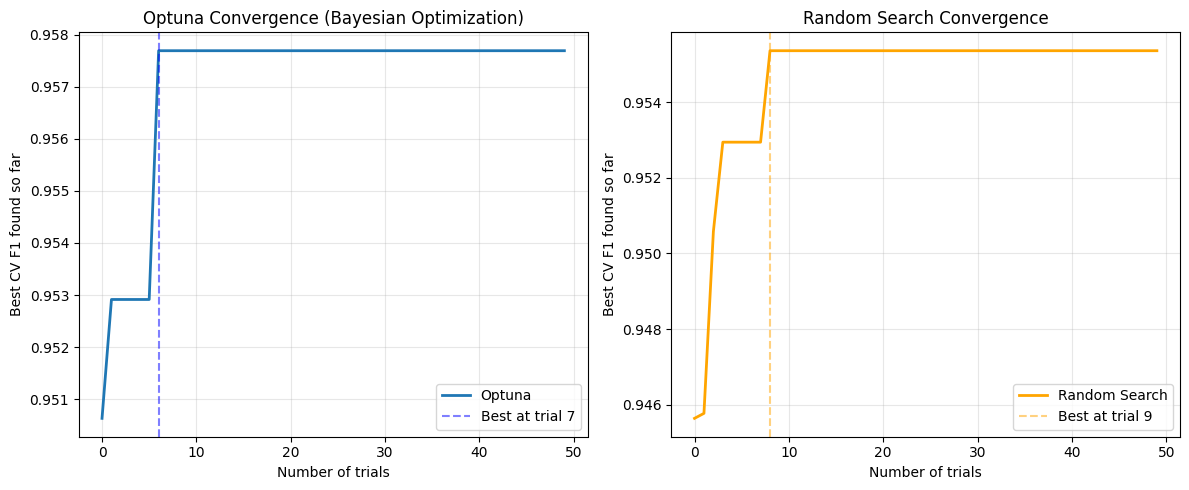


СРАВНЕНИЕ:
Optuna нашла оптимум на trial 7 из 50: 0.9577
Random Search нашла оптимум на trial 9 из 50: 0.9554

Вывод: Optuna использует Байесовскую оптимизацию для более эффективного
поиска, часто находя хорошие решения быстрее, чем случайный поиск.


In [66]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_categorical("max_depth", [None] + list(range(2, 20)))
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    max_features = trial.suggest_categorical("max_features", ['sqrt', 'log2', 0.5])
    
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_macro')
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=False)

optuna_best_values = [max([t.value for t in study.trials[:i+1] if t.value is not None]) for i in range(len(study.trials))]
optuna_best_trial = next(i for i, v in enumerate(optuna_best_values) if v == study.best_value) + 1

rf_trials_scores = [max(rf_random_search.cv_results_['mean_test_score'][:i+1]) for i in range(len(rf_random_search.cv_results_['mean_test_score']))]
rf_best_trial = next(i for i, v in enumerate(rf_trials_scores) if v == max(rf_trials_scores)) + 1

print(f"Optuna нашла лучшее за {optuna_best_trial} trials: {study.best_value:.4f}")
print(f"Random Search нашла лучшее за {rf_best_trial} trials: {max(rf_random_search.cv_results_['mean_test_score']):.4f}")
print(f"\nЛучшие параметры Optuna: {study.best_params}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(optuna_best_values, label='Optuna', linewidth=2)
plt.axvline(x=optuna_best_trial-1, color='blue', linestyle='--', alpha=0.5, label=f'Best at trial {optuna_best_trial}')
plt.xlabel('Number of trials')
plt.ylabel('Best CV F1 found so far')
plt.title('Optuna Convergence (Bayesian Optimization)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rf_trials_scores, label='Random Search', linewidth=2, color='orange')
plt.axvline(x=rf_best_trial-1, color='orange', linestyle='--', alpha=0.5, label=f'Best at trial {rf_best_trial}')
plt.xlabel('Number of trials')
plt.ylabel('Best CV F1 found so far')
plt.title('Random Search Convergence')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("СРАВНЕНИЕ:")
print("="*60)
print(f"Optuna нашла оптимум на trial {optuna_best_trial} из 50: {study.best_value:.4f}")
print(f"Random Search нашла оптимум на trial {rf_best_trial} из 50: {max(rf_random_search.cv_results_['mean_test_score']):.4f}")
print("\nВывод: Optuna использует Байесовскую оптимизацию для более эффективного")
print("поиска, часто находя хорошие решения быстрее, чем случайный поиск.")